In [2]:
import torch
from torch import nn

class RoPEAttention(nn.Module):
    def __init__(self, vocab_size, output_dim, d_model, num_heads): # 加入num_heads参数设置头数量
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads # 按照num_heads切分d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, output_dim)
        self.attn_w = None
    
    def _rotate_half(self, x):
        # x: (batch, num_heads, seq_len, d_k)
        x1 = x[..., ::2]
        x2 = x[..., 1::2]
        return torch.stack((-x2, x1), dim=-1).flatten(-2)

    def _rope(self, q, k, base=10000):
        # q, k: (batch, num_heads, seq_len, d_k)
        seq_len = q.size(-2)   # ← 注意是 -2，不是 1
        freqs = torch.arange(0, self.d_k, 2, device=q.device) / self.d_k
        freqs = base ** freqs                                           # (d_k/2,)
        angles = torch.arange(seq_len, device=q.device)[:, None] / freqs[None, :]  # (seq_len, d_k/2)
        sin = angles.sin().repeat_interleave(2, dim=-1)[None, None]   # (1, 1, seq_len, d_k)
        cos = angles.cos().repeat_interleave(2, dim=-1)[None, None]   # (1, 1, seq_len, d_k)
        return q * cos + self._rotate_half(q) * sin, \
            k * cos + self._rotate_half(k) * sin
    
    def forward(self, x):
        """
        x: (batch, seq_len)
        """
        batch_size = x.size(0)
        x = self.embedding(x)  # (batch, seq_len, d_model)
        Q = self.w_q(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.w_k(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.w_v(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        Q, K = self._rope(Q, K) # 应用RoPE
        # score: (batch, query, key) --- 序列内各位置之间的注意力, query为token位置, key为看的那个位置
        score = Q @ K.transpose(-2, -1) / self.d_k ** 0.5
        attn_w = torch.softmax(score, dim=-1)
        self.attn_w = attn_w.detach()
        output = attn_w @ V # (batch, num_heads, seq_len, d_k)
        output = output.transpose(1, 2).reshape(batch_size, -1, self.d_model) # 将多头的输出拼接回原来的维度
        return self.out(output) # (batch, seq_len, output_dim)


In [4]:
def get_seq_batch(batch, seq_len, vocab_size):
    seq = torch.randint(0, vocab_size, (batch, seq_len), dtype=torch.long)
    idx = torch.randint(0, seq_len, (batch,), dtype=torch.long)
    Q = torch.full((batch, 1), vocab_size, dtype=torch.long)  # 目标 token 是 vocab_size（即 high）这个特殊 token
    x = torch.cat([seq, Q, idx.unsqueeze(1)], dim=1)  # (batch, seq_len)
    y = seq[torch.arange(batch), idx]
    return x, y

epochs = 1000

model = RoPEAttention(vocab_size=11, output_dim=10, d_model=16, num_heads=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(epochs):
    train_x, train_y = get_seq_batch(1024, 10, 10)
    optimizer.zero_grad()
    pred = model(train_x)[:, -1, :]
    loss = criterion(pred, train_y)
    loss.backward()
    optimizer.step()
    if (i+1) % 100 == 0:
        print(f"Epoch {i+1}, Loss: {loss.item():.4f}")

Epoch 100, Loss: 0.0092
Epoch 200, Loss: 0.0012
Epoch 300, Loss: 0.0006
Epoch 400, Loss: 0.0002
Epoch 500, Loss: 0.0002
Epoch 600, Loss: 0.0002
Epoch 700, Loss: 0.0001
Epoch 800, Loss: 0.0001
Epoch 900, Loss: 0.0001
Epoch 1000, Loss: 0.0000


In [8]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False

def plot_attention(attn_w, tokens=None, title="Attention Weights", cmap="Blues"):
    # attn_w: (batch, num_heads, T, T) 或 (num_heads, T, T)
    if attn_w.dim() == 4:
        attn_w = attn_w[0]  # 取第一个样本
    
    num_heads = attn_w.shape[0]
    seq_len = attn_w.shape[1]
    attn_w = attn_w.detach().cpu().float()

    if tokens is None:
        tokens = [str(i) for i in range(seq_len)]

    cell = seq_len * 0.5 + 0.5
    fig, axes = plt.subplots(2, 2, figsize=(cell * 2, cell * 2), constrained_layout=True)

    for n in range(4):
        ax = axes[n // 2][n % 2]
        if n < num_heads:
            im = ax.imshow(attn_w[n], cmap=cmap, vmin=0, vmax=1)
            ax.set_xticks(range(seq_len)); ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=7)
            ax.set_yticks(range(seq_len)); ax.set_yticklabels(tokens, fontsize=7)
            ax.set_title(f"{title} Head-{n}", fontsize=9)
            for i in range(seq_len):
                for j in range(seq_len):
                    val = attn_w[n, i, j].item()
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                            fontsize=6, color="white" if val > 0.6 else "black")
        else:
            ax.axis('off')  # 关闭多余子图

    plt.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
    plt.show()

input : [5, 8, 5, 1, 5, 2, 3, 5, 2, 1, 10, 4]
pred  : 5
target: 5
------------------------------
input : [7, 8, 8, 5, 5, 9, 8, 3, 1, 7, 10, 2]
pred  : 8
target: 8
------------------------------
input : [0, 8, 3, 9, 8, 8, 5, 5, 2, 3, 10, 5]
pred  : 8
target: 8
------------------------------
input : [0, 1, 9, 1, 0, 3, 0, 0, 3, 3, 10, 3]
pred  : 1
target: 1
------------------------------


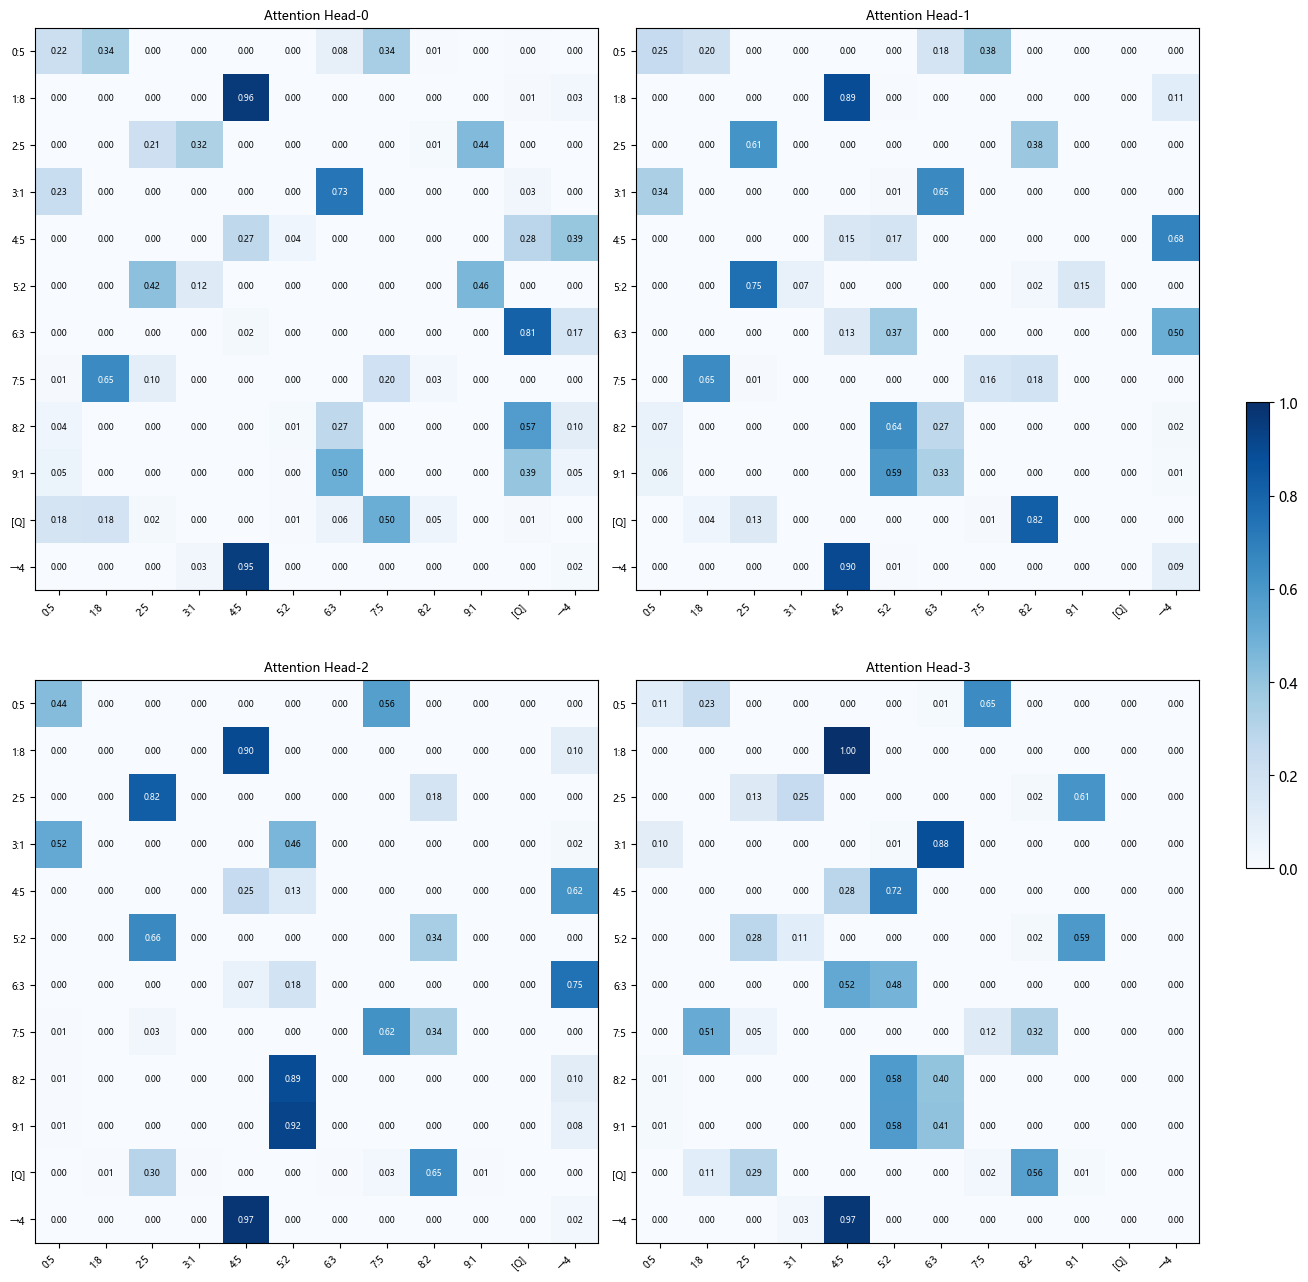

In [12]:
model.eval()
test_x, test_y = get_seq_batch(4, 10, 10)
values = test_x[0, :10].tolist()
q_idx  = test_x[0, -1].item()
query_labels = [f"{i}:{v}" for i, v in enumerate(values)] + ["[Q]", f"→{q_idx}"]
with torch.no_grad():
    pred = model(test_x)[:, -1, :]
    for i in range(test_x.size(0)):
        print(f"input : {test_x[i].tolist()}")
        print(f"pred  : {pred[i].argmax(dim=-1).item()}")
        print(f"target: {test_y[i].item()}")
        print("-" * 30)
    plot_attention(model.attn_w, tokens=query_labels, title="Attention")